# Processing 30 kHz neural data
This notebook gives an overview of how we currently process 30 kHz raw neural data into spikes and spike-band power.

Before running this notebook:   
1. Download an example file containing raw neural recordings
```bash
mkdir -p ../data
cd ../data
wget https://gin.g-node.org/NIN/V1_V4_1024_electrode_resting_state_data/raw/bcf0f801f14e409ee12133aa305293cd32b1707f/data/L_SNR_250717/raw/NSP1_aligned.ns6
```
2. Calculate rereferencing parameters and thresholds for this data
```bash
python calc_params.py -f ../data/NSP1_aligned.ns6 -o ../data/NSP1_aligned_params.json -t -3.5 --reref lrr --plot_spike_panel
```
Once those steps are done, you can proceed.

In [1]:
import json

import brpylib
import matplotlib.pyplot as plt
import numpy as np
from optimizations import OptimizedProcessor
from utils import build_filter, plot_txpanel

DATA_PATH = '../data/NSP1_aligned.ns6'
PARAMS_PATH = '../data/NSP1_aligned_params.json'
MAX_SAMPLES = 10_000  # number of milliseconds to process

In [2]:
# Load NSX file and parameters
nsx_file = brpylib.NsxFile(DATA_PATH)
cont_data = nsx_file.getdata()

file_params = json.load(open(PARAMS_PATH))

In [3]:
# Initialize filter. OptimizedProcessor below builds this same filter
# (4th order, 250-5000 Hz, acausal FIR, 4 ms lag).
n_channels = cont_data['data'][0].shape[0]
acausal_filter_lag = 120
filter_func, sos, zi, rev_win, rev_zi = build_filter(n_channels=n_channels,
                                                     but_low=250,
                                                     but_high=5000,
                                                     causal=False,
                                                     acausal_filter_type='fir',
                                                     acausal_filter_lag=120)

Loading 4 order, [250, 5000] hz bandpass acausal IIR-FIR filter


In [4]:
# Load thresholds and rereferencing weights
reref_params = np.array(file_params['rereference_parameters'])
thresholds = np.array(file_params['thresholds']).reshape(-1, 1)
reref_groups = np.array(file_params['reref_groups'])

In [5]:
# Process one millisecond at a time.
# Each re-referencing group runs on its own thread. Filtering and feature
# extraction then run across channels. With PyTorch and an MPS or CUDA GPU,
# the filter runs there (unified memory is preferred). spike_events and
# spikes_sparse are the raster without the zero bins. decimate=False keeps
# the 30 kHz waveforms plotted below.
sample_rate = (nsx_file.basic_header['SampleResolution'] /
               nsx_file.basic_header['Period'])
samples_per_ms = int(sample_rate / 1000)
ms_per_record = cont_data['data'][0].shape[1] // samples_per_ms
if MAX_SAMPLES is not None:
    ms_per_record = min(ms_per_record, MAX_SAMPLES)

raw = cont_data['data'][0][:, :ms_per_record * samples_per_ms]
with OptimizedProcessor(
        n_channels=n_channels,
        reref_params=reref_params,
        thresholds=thresholds,
        reref_groups=reref_groups,
        sample_rate=sample_rate,
        per_array_threads=True,
        per_channel_threads=True,
        use_gpu='auto',
        decimate=False,
) as processor:
    result = processor.process_recording(raw)

spikes = result.spikes
spike_band_power = result.spike_band_power
filtered_data = result.filtered
rereferenced_data = result.rereferenced
spike_events = result.spike_events
spikes_sparse = result.spikes_sparse

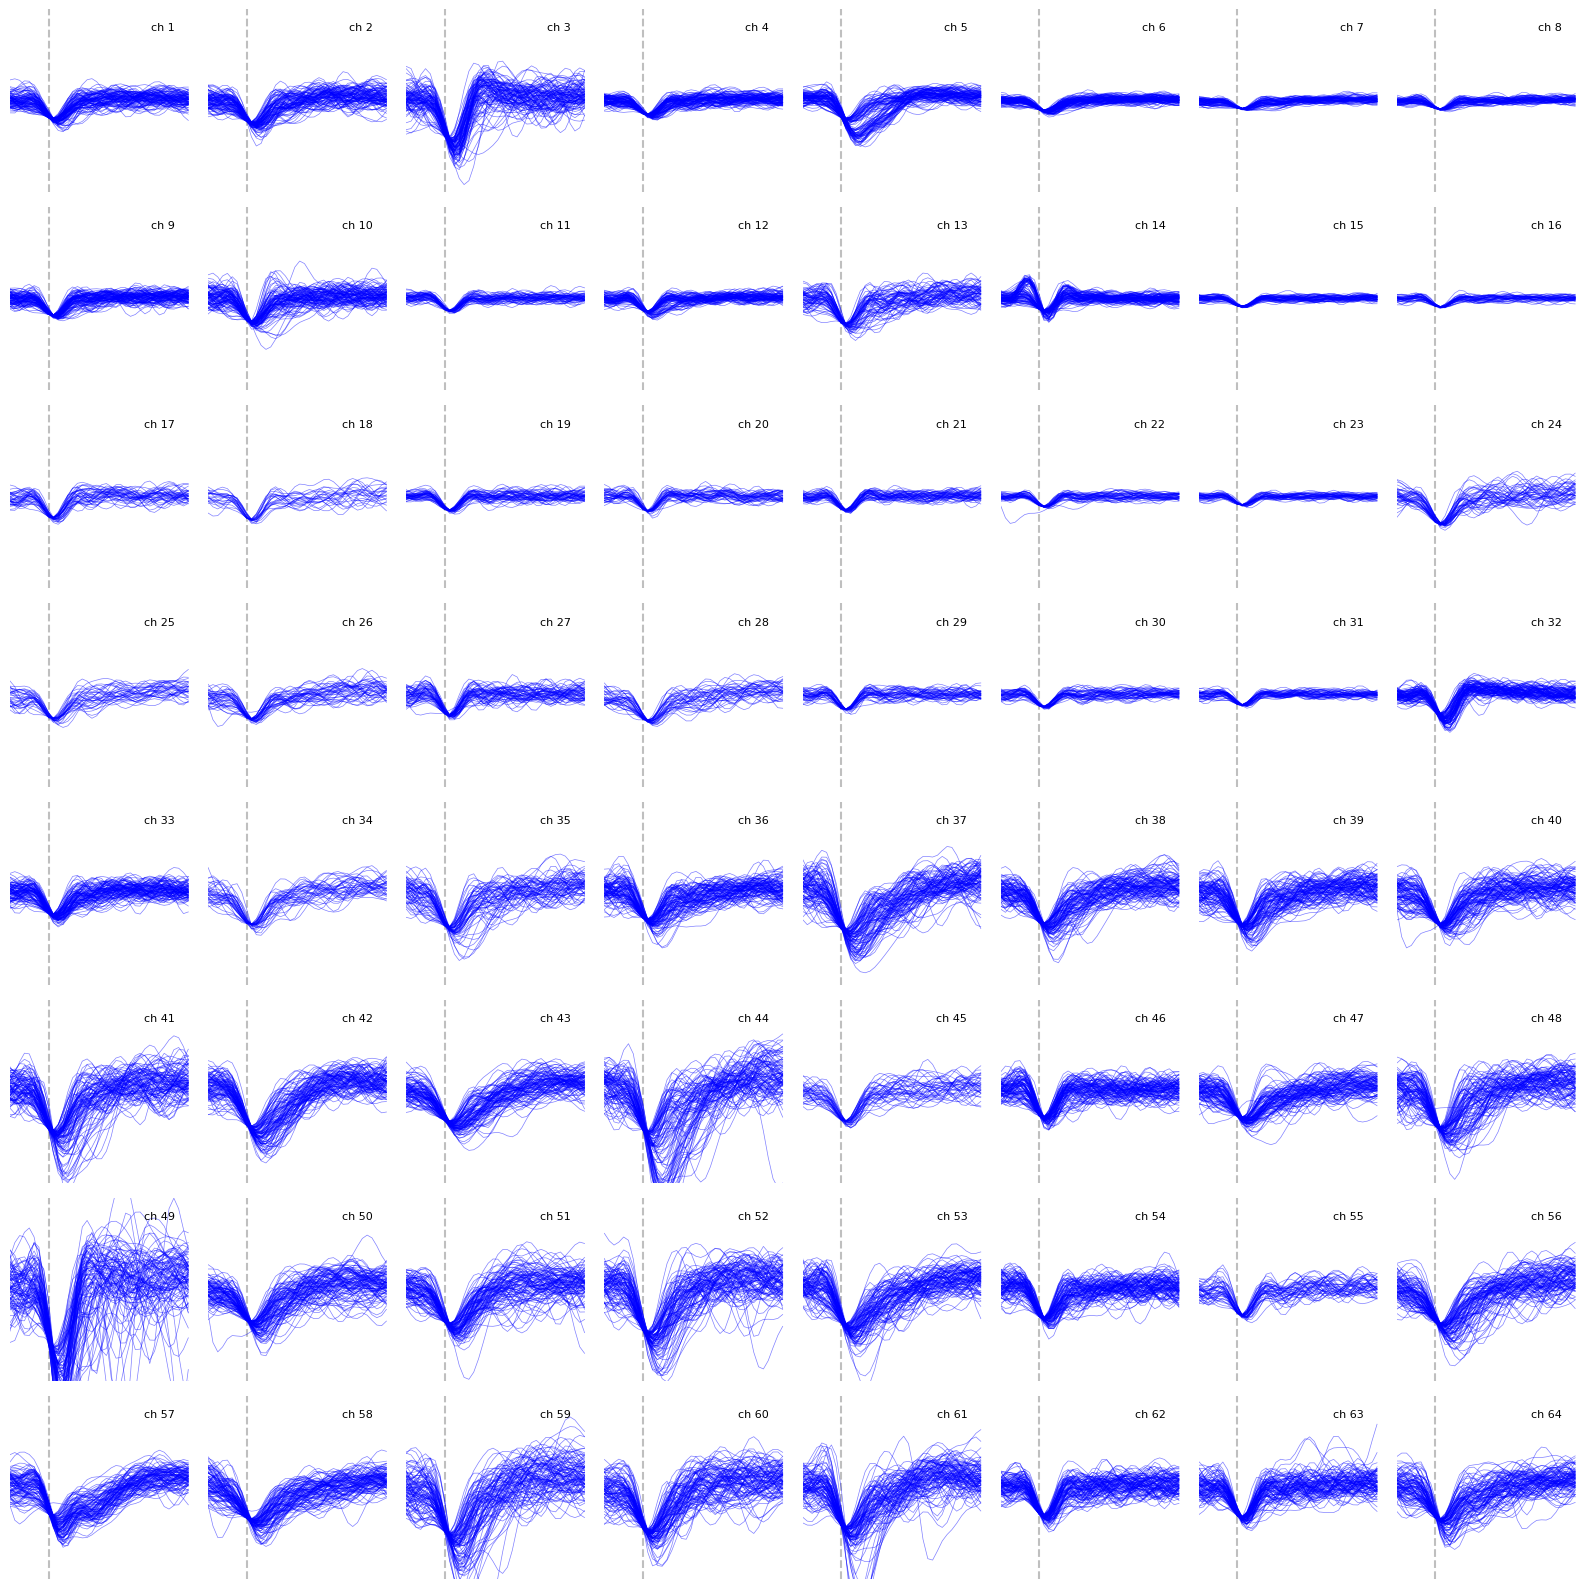

In [6]:
# Plot spike panels
mask = ~np.any(np.isnan(filtered_data), axis=0)  # exclude NaNs
plot_txpanel(filtered_data[:, mask],
             channels=reref_groups[0],
             thresholds=thresholds,
             max_samples=300_000)
plt.show()

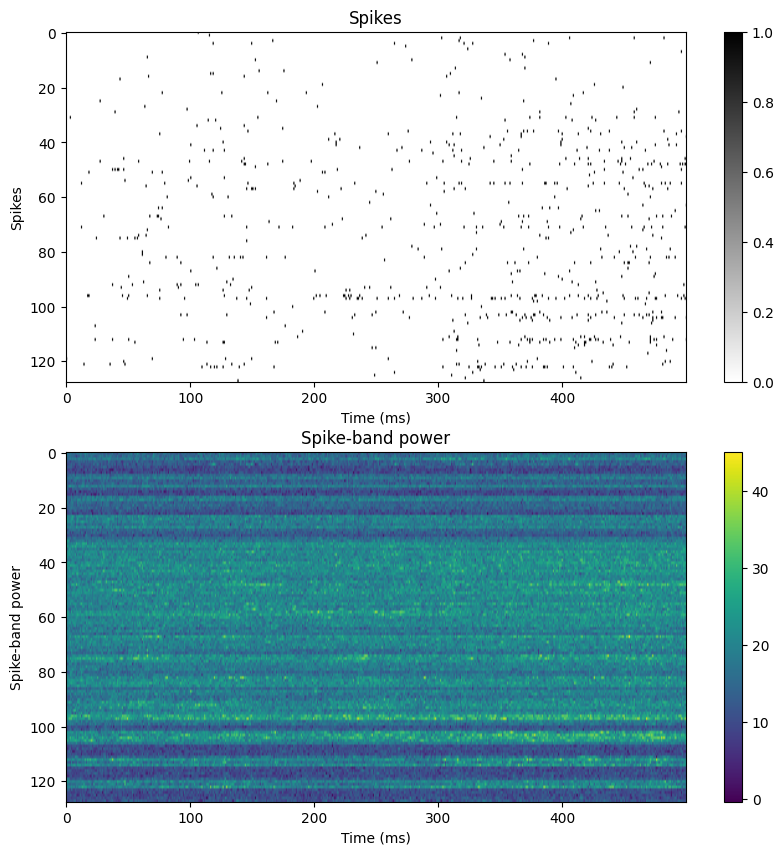

In [7]:
# Plot features
start_time = 0.1
end_time = 0.6
start_time_samples = int(start_time * sample_rate)
end_time_samples = int(end_time * sample_rate)
start_time_idx = start_time_samples // samples_per_ms
end_time_idx = end_time_samples // samples_per_ms

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
# spikes
ax = axes[0]
im = ax.imshow(spikes[:, start_time_idx:end_time_idx],
               aspect='auto',
               cmap='binary')
ax.set_title('Spikes')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spikes')
plt.colorbar(im, ax=ax)
# spike-band power
ax = axes[1]
im = ax.imshow(spike_band_power[:, start_time_idx:end_time_idx], aspect='auto')
ax.set_title('Spike-band power')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spike-band power')
plt.colorbar(im, ax=ax)
plt.show()

## Optimizations in this run

The processing cell uses `OptimizedProcessor` (`optimizations.py`):

- one thread per re-referencing group (each multi-electrode array)
- filtering and feature extraction across channels
- GPU filtering when PyTorch can see MPS (unified memory) or CUDA
- `spike_events` and `spikes_sparse`, the raster stored without the zero bins

`decimate=False` here, so the plots are the full 30 kHz pipeline. Set `decimate=True` to low-pass at 6 kHz and keep every other sample before the same feature extraction. That is lossy and will not match the plots above.